# Measures of Dispersion

- Range
-  Variance
-  Standard Deviation
-  Coefficient of Variation (CV)
-  Interquartile Range (IQR)

In [1]:
import numpy as np
import pandas as pd
from scipy import stats

## Range
- To quickly check how much data is spread.
- Range = Maximum Value - Minimum Value

###### E-commerce Daily Sales
-  What is the difference between the highest and lowest sales?

In [2]:
sales = [12000,15000,14500,13000,25000]

In [4]:
range_value = np.max(sales) - np.min(sales)

In [5]:
range_value

np.int64(13000)

In [6]:
# using ptp method
np.ptp(sales)

np.int64(13000)

In [7]:
print('Minimum sale : ',np.min(sales))
print('Maximum sale : ',np.max(sales))
print('Diffrence : ',np.ptp(sales))

Minimum sale :  12000
Maximum sale :  25000
Diffrence :  13000


#### When there are outliers

In [8]:
sales2 = [100,102,101,103,5000]

In [12]:
np.ptp(sales2)

np.int64(4900)

- Most sales are around 100,  and range suggests a very large spread. 
- because one value makes the range huge that make the range misleading.
- Range depends only on the minimum and maximum values.


# 

## Variance
measure how far each data value is from mean

In [13]:
# Sample Sales Data
df = pd.DataFrame({"Sales": [120, 150, 180, 200, 220, 250, 280, 300, 350, 400]})

In [14]:
df

,Sales
0,120
1,150
2,180
3,200
4,220
5,250
6,280
7,300
8,350
9,400


In [15]:
population_variance = np.var(df["Sales"])          # Population Variance

In [16]:
population_variance

7085.0

In [17]:
sample_variance = np.var(df["Sales"], ddof=1)      # Sample Variance

In [18]:
sample_variance

7872.222222222223

##### - result are show in squared units, difficult to interpret so we can use Standard Deviation return result in same unit as the original data

# 

## Standard Deviation
- It is the square root of the variance, so the result is in the same unit as the original data, making it easier to interpret.

In [24]:
print(np.std(df["Sales"],ddof=1))

88.72554436137443


###### Population Standard Deviation : When you have the entire population.

In [26]:
print(np.sqrt(population_variance))

84.17244204607586


In [27]:
print(np.std(df["Sales"]))

84.17244204607586


###### Sample Standard Deviation : When your data is a sample from a larger population

In [32]:
print(np.sqrt(sample_variance))

88.72554436137443


In [34]:
print(np.std(df["Sales"],ddof=1))

88.72554436137443


In [38]:
print('Mean of data :',np.mean(df['Sales']))

Mean of data : 245.0


###### what I undestand :
- Some values are higher than the mean and some are lower, with a typical distance of about around 84.18 units from the mean.

# 

## Coefficient of Variation
It expresses the standard deviation as a percentage of the mean.

In [44]:
cv = stats.variation(df["Sales"], ddof=1) * 100
print(f"CV: {cv:.2f}%")

CV: 36.21%


In [47]:
mean = df["Sales"].mean()
std = df["Sales"].std()

cv = (std / mean) * 100

print("Mean:", mean)
print("Standard Deviation:", std)
print("Coefficient of Variation (CV):", cv)

Mean: 245.0
Standard Deviation: 88.72554436137443
Coefficient of Variation (CV): 36.21450790260181


###### CV is 36.21 %, meaning the standard deviation is 36.21% of the mean, indicating moderate variability in sales.

### Interquartile Range (IQR)
measures the spread of the middle 50% of the data

In [58]:
# Quartiles
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

# IQR
IQR = Q3 - Q1


print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 185.0
Q3: 295.0
IQR: 110.0


In [57]:
# Direct Method (SciPy)
IQR = stats.iqr(df["Sales"])
print("IQR:", IQR)

IQR: 110.0


###### The middle 50% of the sales values -  between 185 and 295, so their spread is 110 units.

# 

## Visualization

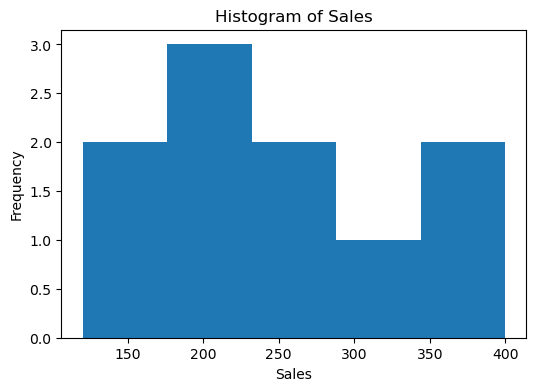

In [64]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.hist(df["Sales"], bins=5)
plt.title("Histogram of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

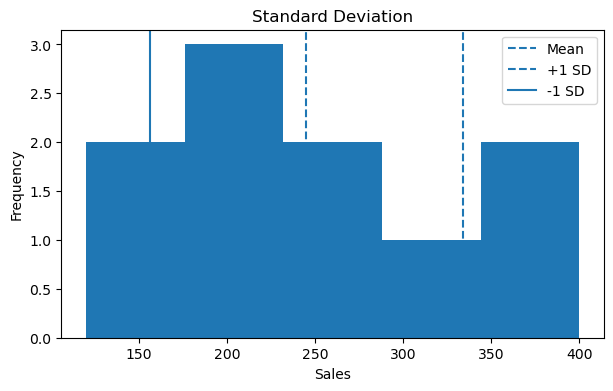

In [74]:
mean = df["Sales"].mean()
std = df["Sales"].std()

plt.figure(figsize=(7,4))
plt.hist(df["Sales"], bins=5)

plt.axvline(mean, linestyle="--", label="Mean")
plt.axvline(mean + std, linestyle="--", label="+1 SD")
plt.axvline(mean - std, linestyle="-", label="-1 SD")

plt.title("Standard Deviation")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.legend()
plt.show()

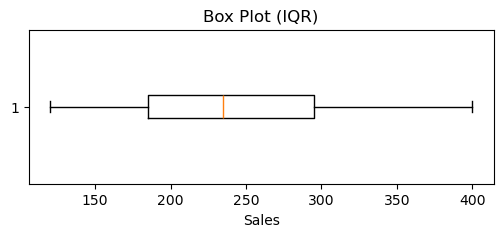

In [85]:
plt.figure(figsize=(6,2))
plt.boxplot(df["Sales"], vert=False)

plt.title("Box Plot (IQR)")
plt.xlabel("Sales")
plt.show()